In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

df= pd.read_csv('/kaggle/input/snappfood-persian-sentiment-analysis/Snappfood - Sentiment Analysis.csv',encoding='utf-8', sep='\t+', on_bad_lines='skip')

df = df.head(70000)
df = df[['comment', 'label']]
df = df.dropna()

<ipython-input-1-56b80e2b411b>:4: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df= pd.read_csv('/kaggle/input/snappfood-persian-sentiment-analysis/Snappfood - Sentiment Analysis.csv',encoding='utf-8', sep='\t+', on_bad_lines='skip')


In [2]:
!pip install hazm

In [3]:
from hazm import Normalizer

# نرمال‌سازی متن‌ها
normalizer = Normalizer()

def preprocess_text(text):
    # حذف فاصله‌های اضافی، تبدیل اعداد انگلیسی به فارسی، و نرمال‌سازی متن
    return normalizer.normalize(text)

# اعمال پیش‌پردازش روی ستون 'comment'
df['comment'] = df['comment'].apply(preprocess_text)

# بررسی نتیجه
print(df.head())

# ذخیره دیتاست پیش‌پردازش شده
# data.to_csv("Snappfood-Sentiment Analysis_preprocessed.csv", index=False)
# print("پیش‌پردازش انجام شد و دیتاست ذخیره گردید.")

                                             comment  label
0    واقعا حیف وقت که بنویسم سرویس دهیتون شده افتضاح    SAD
1  قرار بود ۱ ساعته برسه ولی نیم ساعت زودتر از مو...  HAPPY
2  قیمت این مدل اصلا با کیفیتش سازگاری نداره، فقط...    SAD
3  عالی بود همه چه درست و به اندازه و کیفیت خوب، ...  HAPPY
4                      شیرینی وانیلی فقط یک مدل بود.  HAPPY


In [4]:
def map_labels(label):
    if label == "HAPPY":
        return 1
    else:
        return 0


df['label'] = df['label'].apply(map_labels)

In [5]:
print(df['label'].value_counts())

label
0    35000
1    35000
Name: count, dtype: int64


In [6]:
df['comment_length'] = df['comment'].apply(len)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


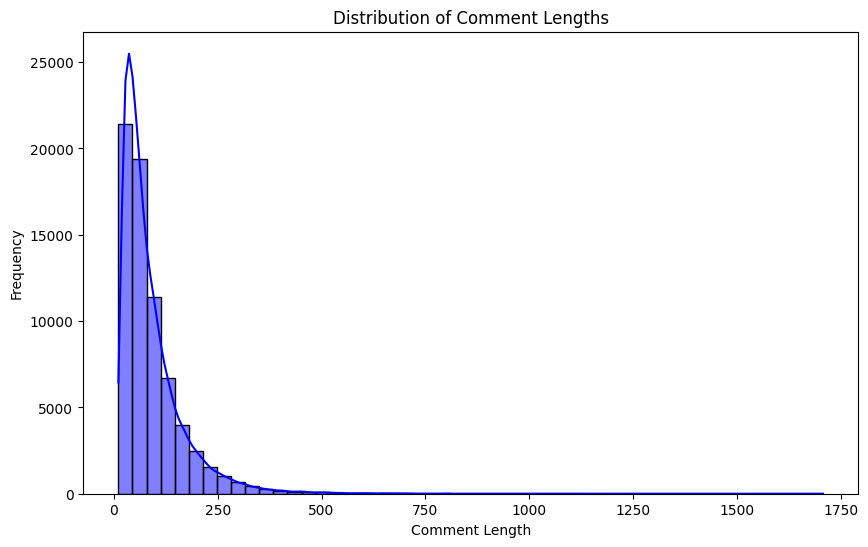

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['comment_length'], bins=50, kde=True, color='blue')
plt.title('Distribution of Comment Lengths')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()

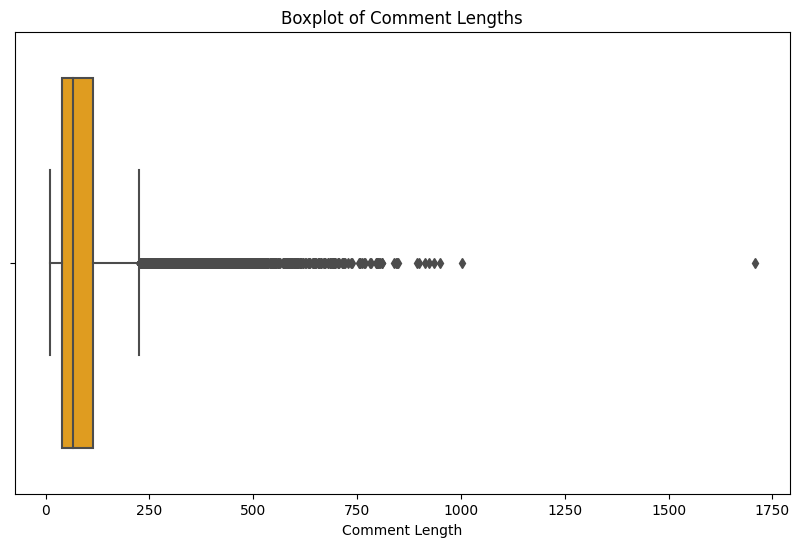

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['comment_length'], color='orange')
plt.title('Boxplot of Comment Lengths')
plt.xlabel('Comment Length')
plt.show()


In [9]:
# محاسبه چارک‌ها و IQR
Q1 = df['comment_length'].quantile(0.25)
Q3 = df['comment_length'].quantile(0.75)
IQR = Q3 - Q1

# تعیین حدود
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Upper limit: {lower_bound}")
print(f"Lower limit: {upper_bound}")

# حذف داده‌های پرت
cleaned_df = df[(df['comment_length'] >= lower_bound) & (df['comment_length'] <= upper_bound)]
print(f"تعداد داده‌های باقی‌مانده: {cleaned_df.shape[0]}")

Upper limit: -73.5
Lower limit: 226.5
تعداد داده‌های باقی‌مانده: 66024


In [10]:
# شمارش داده‌هایی که طول متن آن‌ها بیشتر از 226 است
greater_than_226 = df[df['comment_length'] > 226].shape[0]

# شمارش داده‌هایی که طول متن آن‌ها بین 0 تا 226 است
between_0_and_226 = df[(df['comment_length'] > 0) & (df['comment_length'] <= 226)].shape[0]

print(f"تعداد داده‌هایی که طول متن آن‌ها بیشتر از 226 است: {greater_than_226}")
print(f"تعداد داده‌هایی که طول متن آن‌ها بین 0 تا 226 است: {between_0_and_226}")

تعداد داده‌هایی که طول متن آن‌ها بیشتر از 226 است: 3976
تعداد داده‌هایی که طول متن آن‌ها بین 0 تا 226 است: 66024


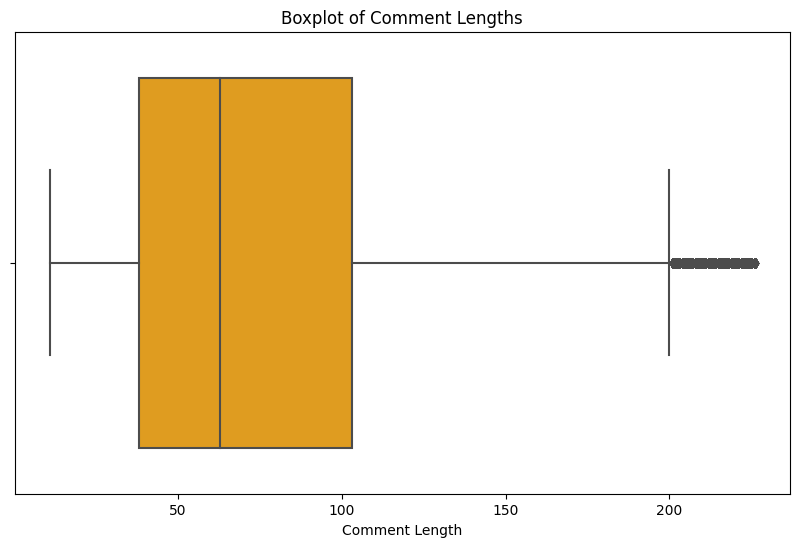

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=cleaned_df['comment_length'], color='orange')
plt.title('Boxplot of Comment Lengths')
plt.xlabel('Comment Length')
plt.show()

In [12]:
# محاسبه چارک‌ها و IQR
Q1 = cleaned_df['comment_length'].quantile(0.25)
Q3 = cleaned_df['comment_length'].quantile(0.75)
IQR = Q3 - Q1

# تعیین حدود
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Upper limit: {lower_bound}")
print(f"Lower limit: {upper_bound}")

# حذف داده‌های پرت
cleaned_df = cleaned_df[(cleaned_df['comment_length'] >= lower_bound) & (cleaned_df['comment_length'] <= upper_bound)]
print(f"تعداد داده‌های باقی‌مانده: {cleaned_df.shape[0]}")

Upper limit: -59.5
Lower limit: 200.5
تعداد داده‌های باقی‌مانده: 64496


# 2 times cleaning
## Outlier datas were cleared twice.

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


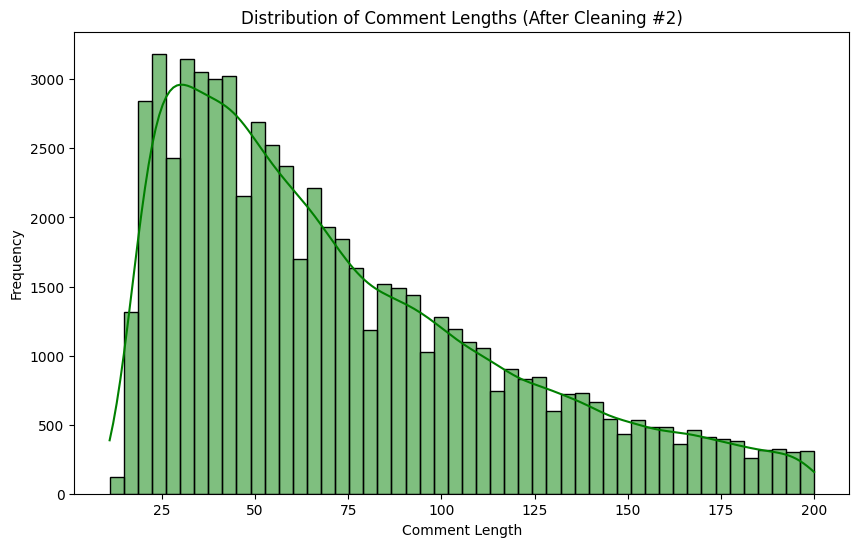

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(cleaned_df['comment_length'], bins=50, kde=True, color='green')
plt.title('Distribution of Comment Lengths (After Cleaning #2)')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()

In [14]:
# حذف ردیف‌هایی که داده‌های خالی دارند
cleaned_df = cleaned_df.dropna()

# حذف ستون‌هایی که داده‌های خالی زیادی دارند
cleaned_df = cleaned_df.dropna(axis=1)

In [15]:
# شمارش داده‌های تکراری
print(f"تعداد داده‌های تکراری: {cleaned_df.duplicated().sum()}")

# حذف داده‌های تکراری
cleaned_df = cleaned_df.drop_duplicates()

تعداد داده‌های تکراری: 51


In [16]:
import re

def clean_comment(comment):
    comment = re.sub(r'\s+', ' ', comment)  # حذف فاصله‌های اضافی
    comment = re.sub(r'http\S+', '', comment)  # حذف لینک‌ها
    comment = re.sub(r'[^\w\s]', '', comment)  # حذف کاراکترهای خاص
    comment = re.sub(r'\d+', '', comment)  # حذف اعداد
    return comment.strip()

cleaned_df['comment_cleaned'] = cleaned_df['comment'].apply(clean_comment)

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


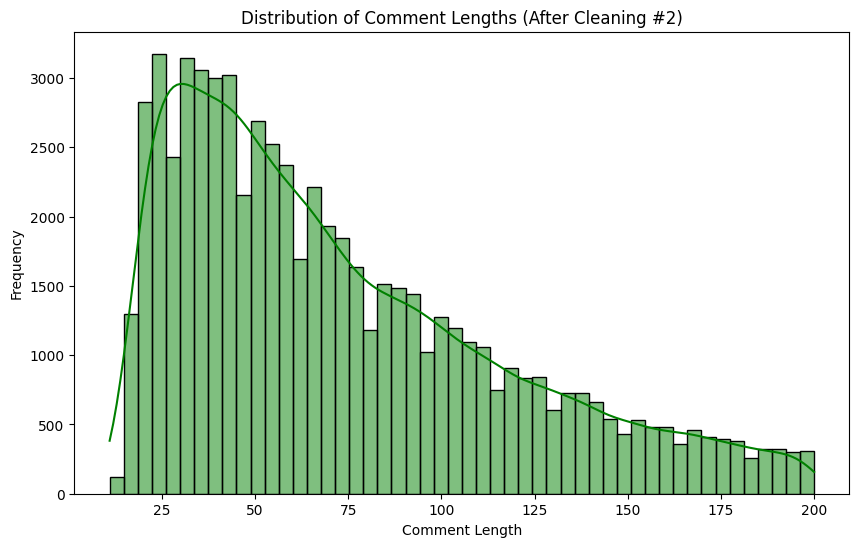

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(cleaned_df['comment_length'], bins=50, kde=True, color='green')
plt.title('Distribution of Comment Lengths (After Cleaning #2)')
plt.xlabel('Comment Length')
plt.ylabel('Frequency')
plt.show()

In [18]:
print(cleaned_df['label'].value_counts())

label
1    33118
0    31327
Name: count, dtype: int64


In [19]:

# شمارش داده‌هایی که طول متن آن‌ها بین 0 تا 17 است
between_0_and_17 = df[(df['comment_length'] > 0) & (df['comment_length'] <= 17)].shape[0]

print(f"تعداد داده‌هایی که طول متن آن‌ها بین 0 تا 17 است: {between_0_and_17}")

تعداد داده‌هایی که طول متن آن‌ها بین 0 تا 17 است: 931


In [22]:
# تقسیم داده‌ها به سه مجموعه (آموزش 50%، اعتبارسنجی 20%، تست 30%)
train_data, temp_data = train_test_split(cleaned_df, test_size=0.5, stratify=cleaned_df['label'], random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.6, stratify=temp_data['label'], random_state=42)


print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")
print(f"Test samples: {len(test_data)}")

# ذخیره داده‌ها برای استفاده‌های بعدی
train_data.to_csv("snappfood_train.csv", index=False)
val_data.to_csv("snappfood_val.csv", index=False)
test_data.to_csv("snappfood_test.csv", index=False)

print("دیتاست آماده شد و ذخیره گردید.")

Training samples: 31765
Validation samples: 12706
Test samples: 19059
دیتاست آماده شد و ذخیره گردید.


In [23]:
!pip install transformers

In [24]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import DataLoader, Dataset
import torch
import pandas as pd

In [25]:
# بارگذاری مدل و توکنایزر ParsBERT
MODEL_NAME = "HooshvareLab/bert-fa-base-uncased-sentiment-snappfood"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# تعریف کلاس دیتاست برای PyTorch
class snappfoodDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        text = self.texts[index]
        label = self.labels[index]

        # توکنایز کردن متن
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long),
        }

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [26]:
# بارگذاری داده‌های تقسیم‌شده
train_data = pd.read_csv("snappfood_train.csv")
val_data = pd.read_csv("snappfood_val.csv")
test_data = pd.read_csv("snappfood_test.csv")

In [27]:
# تعریف دیتاست‌ها
train_dataset = snappfoodDataset(
    texts=train_data["comment"].tolist(),
    labels=train_data["label"].tolist(),
    tokenizer=tokenizer,
    max_len=128,
)

val_dataset = snappfoodDataset(
    texts=val_data["comment"].tolist(),
    labels=val_data["label"].tolist(),
    tokenizer=tokenizer,
    max_len=128,
)

test_dataset = snappfoodDataset(
    texts=test_data["comment"].tolist(),
    labels=test_data["label"].tolist(),
    tokenizer=tokenizer,
    max_len=128,
)

In [28]:
# تعریف DataLoader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("مدل و داده‌ها آماده شدند.")

مدل و داده‌ها آماده شدند.


In [29]:
 # تا اینجا   
# بقیه رو هم خودم زدم

In [30]:
# انتقال مدل به GPU در صورت وجود
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [1]:
import torch
import time
from torch.optim import AdamW
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# افزودن Dropout و L2 Regularization
class CustomParsBERT(nn.Module):
    def __init__(self, model, dropout_prob=0.3, l2_lambda=0.01):
        super(CustomParsBERT, self).__init__()
        self.bert = model.bert
        self.dropout = nn.Dropout(p=dropout_prob)
        self.classifier = nn.Linear(model.config.hidden_size, model.config.num_labels)
        self.l2_lambda = l2_lambda

    def forward(self, input_ids, attention_mask, labels=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = self.dropout(outputs.pooler_output)
        logits = self.classifier(pooled_output)

        if labels is not None:
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

            # افزودن L2 Regularization
            l2_reg = sum(param.norm(2) for param in self.classifier.parameters())
            loss += self.l2_lambda * l2_reg

            return loss, logits
        return logits

# آماده‌سازی مدل با لایه‌های جدید
model = CustomParsBERT(model)
model.to(device)

# بهینه‌ساز
optimizer = AdamW(model.parameters(), lr=0.0001)

# callbacks
class ReduceLROnPlateau:
    def __init__(self, monitor='val_loss', patience=3, factor=0.3, verbose=1):
        self.monitor = monitor
        self.patience = patience
        self.factor = factor
        self.verbose = verbose
        self.wait = 0
        self.best_score = float('inf')

    def step(self, current_score):
        if current_score < self.best_score:
            self.best_score = current_score
            self.wait = 0
        else:
            self.wait += 1

        if self.wait >= self.patience:
            for g in optimizer.param_groups:
                g['lr'] *= self.factor
            if self.verbose:
                print(f"Reducing learning rate to {optimizer.param_groups[0]['lr']}")

class EarlyStopping:
    def __init__(self, monitor='val_loss', patience=5):
        self.monitor = monitor
        self.patience = patience
        self.wait = 0
        self.best_score = float('inf')
        self.stop_training = False

    def step(self, current_score):
        if current_score < self.best_score:
            self.best_score = current_score
            self.wait = 0
        else:
            self.wait += 1

        if self.wait >= self.patience:
            self.stop_training = True

# تعریف callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.3, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5)

# حلقه آموزش
num_epochs = 20
for epoch in range(num_epochs):
    print(f"Epoch {epoch + 1}/{num_epochs}")
    start_time = time.time()

    # آموزش مدل
    model.train()
    train_loss = 0
    train_preds, train_labels = [], []

    for batch in tqdm(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        loss, logits = model(input_ids, attention_mask, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        train_preds.extend(preds)
        train_labels.extend(labels.cpu().numpy())

    # ارزیابی مدل روی داده اعتبارسنجی
    model.eval()
    val_loss = 0
    val_preds, val_labels = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            loss, logits = model(input_ids, attention_mask, labels)
            val_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            val_preds.extend(preds)
            val_labels.extend(labels.cpu().numpy())

    # محاسبه معیارها
    train_accuracy = accuracy_score(train_labels, train_preds)
    train_precision = precision_score(train_labels, train_preds, average='weighted')
    train_recall = recall_score(train_labels, train_preds, average='weighted')
    train_f1 = f1_score(train_labels, train_preds, average='weighted')

    val_accuracy = accuracy_score(val_labels, val_preds)
    val_precision = precision_score(val_labels, val_preds, average='weighted')
    val_recall = recall_score(val_labels, val_preds, average='weighted')
    val_f1 = f1_score(val_labels, val_preds, average='weighted')

    end_time = time.time()
    epoch_time = end_time - start_time

    # پرینت نتایج
    print(f"Training Loss: {train_loss / len(train_loader):.4f}")
    print(f"Training Accuracy: {train_accuracy:.4f}")
    print(f"Training Precision: {train_precision:.4f}")
    print(f"Training Recall: {train_recall:.4f}")
    print(f"Training F1-Score: {train_f1:.4f}")
    print(f"Validation Loss: {val_loss / len(val_loader):.4f}")
    print(f"Validation Accuracy: {val_accuracy:.4f}")
    print(f"Validation Precision: {val_precision:.4f}")
    print(f"Validation Recall: {val_recall:.4f}")
    print(f"Validation F1-Score: {val_f1:.4f}")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
    print(f"Epoch Time: {epoch_time:.2f} seconds")

    # استفاده از callbacks
    reduce_lr.step(val_loss / len(val_loader))
    early_stopping.step(val_loss / len(val_loader))
    if early_stopping.stop_training:
        print("Early stopping triggered!")
        break

print("آموزش مدل به پایان رسید.")


NameError: name 'model' is not defined

In [ ]:
outputs = model(input_ids, attention_mask, labels=None)
print(outputs)  # بررسی اینکه مدل چه چیزی را برمی‌گرداند

In [33]:
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # دریافت logits از مدل
            logits = model(input_ids, attention_mask, labels=None)

            # محاسبه پیش‌بینی‌ها
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    # محاسبه معیارهای عملکرد
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print("Test Results:")
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")

evaluate_model(model, test_loader, device)


100%|██████████| 596/596 [01:08<00:00,  8.65it/s]


Test Results:
  Accuracy: 0.5123
  Precision: 0.2624
  Recall: 0.5123
  F1-Score: 0.3470


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [2]:
from sklearn.metrics import roc_curve, auc

# تابع ارزیابی برای محاسبه ROC
def evaluate_roc_curve(model, dataloader, device):
    model.eval()
    all_probs, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(dataloader):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids, attention_mask, labels=None)  # فقط logits دریافت می‌شود
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()  # احتمال کلاس مثبت
            all_probs.extend(probs)
            all_labels.extend(labels.cpu().numpy())

    # محاسبه FPR، TPR و AUC
    fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)

    # رسم منحنی ROC
    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.grid()
    plt.show()

# ارزیابی مدل و رسم منحنی ROC
print("Plotting ROC curve...")
evaluate_roc_curve(model, test_loader, device)


Plotting ROC curve...


NameError: name 'model' is not defined

In [ ]:
# ذخیره کردن وزن‌ها و وضعیت مدل
torch.save(model.state_dict(), 'model.pth')

In [ ]:
# ذخیره کردن مدل به همراه معماری
torch.save(model, 'full_model.pth')